# Obesity Risk Classification using Random Forest

## A Comprehensive Guide to Understanding the Problem, Data, and Machine Learning Model

---

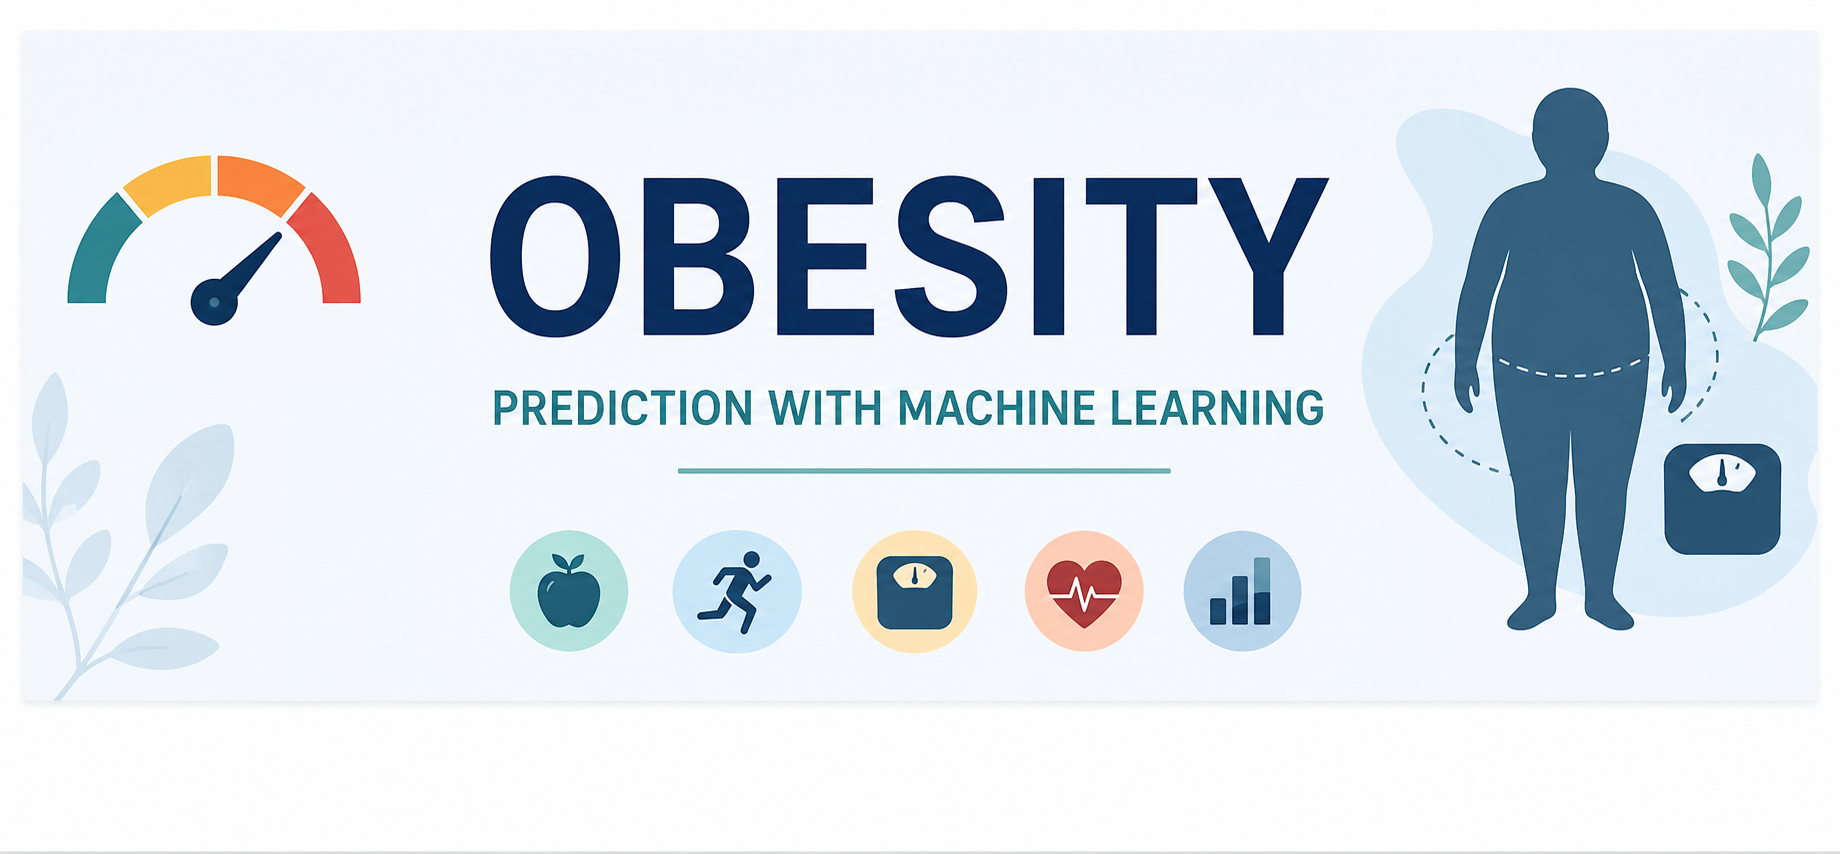

## Part 1: Problem Definition

### What Problem Are We Solving?

**Obesity is a serious global health concern.** This project aims to:
- **Predict obesity risk levels** based on health and lifestyle factors
- **Classify individuals** into obesity categories (Insufficient Weight, Normal Weight, Overweight I, Overweight II, Obesity Type I, II, or III)
- **Help healthcare professionals** identify at-risk individuals early
- **Enable personalized interventions** based on predicted obesity levels

### Why This Matters
- Obesity leads to serious health conditions (diabetes, heart disease, cancer)
- Early prediction enables preventive healthcare
- Machine learning can identify complex patterns in health data

### Dataset Overview
- **Total Records**: 20,758 individuals
- **Features**: 18 columns (17 input features + 1 target variable)
- **Target Variable**: Obesity level (categorical)
- **Source**: Kaggle - Obesity Risk Dataset

---

## Part 2: Understanding the Dataset & Features

### Complete Feature Explanation

#### **Demographic Features**
1. **id** - Unique identifier for each person (not used in model)
2. **Gender** - Male or Female (categorical)
   - *Why needed*: Different genders may have different obesity patterns

3. **Age** - Age in years (numerical)
   - *Why needed*: Obesity risk changes with age; metabolism varies across life stages

#### **Physical Features**
4. **Height** - Height in meters (numerical)
   - *Why needed*: Used to calculate BMI; essential for obesity assessment

5. **Weight** - Weight in kilograms (numerical)
   - *Why needed*: Primary indicator of body mass; combined with height for BMI

#### **Medical/Family History**
6. **family_history_with_overweight** - Binary (1=Yes, 0=No) 
   - *Why needed*: Genetics influence obesity;Has a family member suffered or suffers from overweight?

#### **Dietary Habits**
7. **FAVC** - Frequent Consumption of High Caloric Food (1=Yes, 0=No)
   - *Why needed*: High-calorie food consumption directly increases obesity risk(Do you eat high caloric food frequently?)
   
8. **FCVC** - Frequency of Vegetable Consumption (0-4 scale)
   - *Why needed*: More vegetables = healthier diet = lower obesity risk(Do you usually eat vegetables in your meals?)
   
9. **NCP** - Number of Main Meals per Day (numerical, typically 1-4)
   - *Why needed*: Meal frequency affects metabolism and weight gain patterns(How many main meals do you have daily?)

10. **CAEC** - Consumption of Food Between Meals (categorical: Sometimes, Frequently, Always, No)
    - *Why needed*: Snacking between meals adds extra calories and increases obesity risk(Do you eat any food between meals?)

#### **Lifestyle Habits**
11. **SMOKE** - Smoking Status (1=Yes, 0=No)
    - *Why needed*: Smokers often have different weight patterns; affects metabolism

12. **CH2O** - Daily Water Consumption in Liters (numerical)
    - *Why needed*: Adequate water intake supports healthy metabolism and weight management(How much water do you drink daily?)

13. **SCC** - Consumption of Caloric Beverages (1=Yes, 0=No)
    - *Why needed*: Sugary drinks add significant calories; major obesity contributor(Do you monitor the calories you eat daily?)

14. **FAF** - Frequency of Physical Activity in days/week (numerical, 0-7)
    - *Why needed*: Exercise burns calories; more activity = lower obesity risk(How often do you have physical activity?)

15. **TUE** - Time Using Technology/Screen Time in hours (numerical)
    - *Why needed*: Sedentary behavior increases obesity risk(How much time do you use technological devices such as cell phone, videogames, television, computer and others?)

#### **Additional Factors**
16. **CALC** - Alcohol Consumption (categorical: No, Sometimes, Always, Frequently)
    - *Why needed*: Alcohol contains empty calories; affects weight(How often do you drink alcohol?)

17. **MTRANS** - Mode of Transportation (categorical: Automobile, Motorbike, Bike, Public_Transportation, Walking)
    - *Why needed*: Active transportation (walking, biking) burns calories vs. passive (car, motorbike)

#### **Target Variable**
18. **0be1dad** (Or similar column) - Obesity Level (categorical)
    - **Possible Values**:
      - Insufficient_Weight
      - Normal_Weight
      - Overweight_Level_I
      - Overweight_Level_II
      - Obesity_Type_I
      - Obesity_Type_II
      - Obesity_Type_III
    - *This is what we want to PREDICT*

---

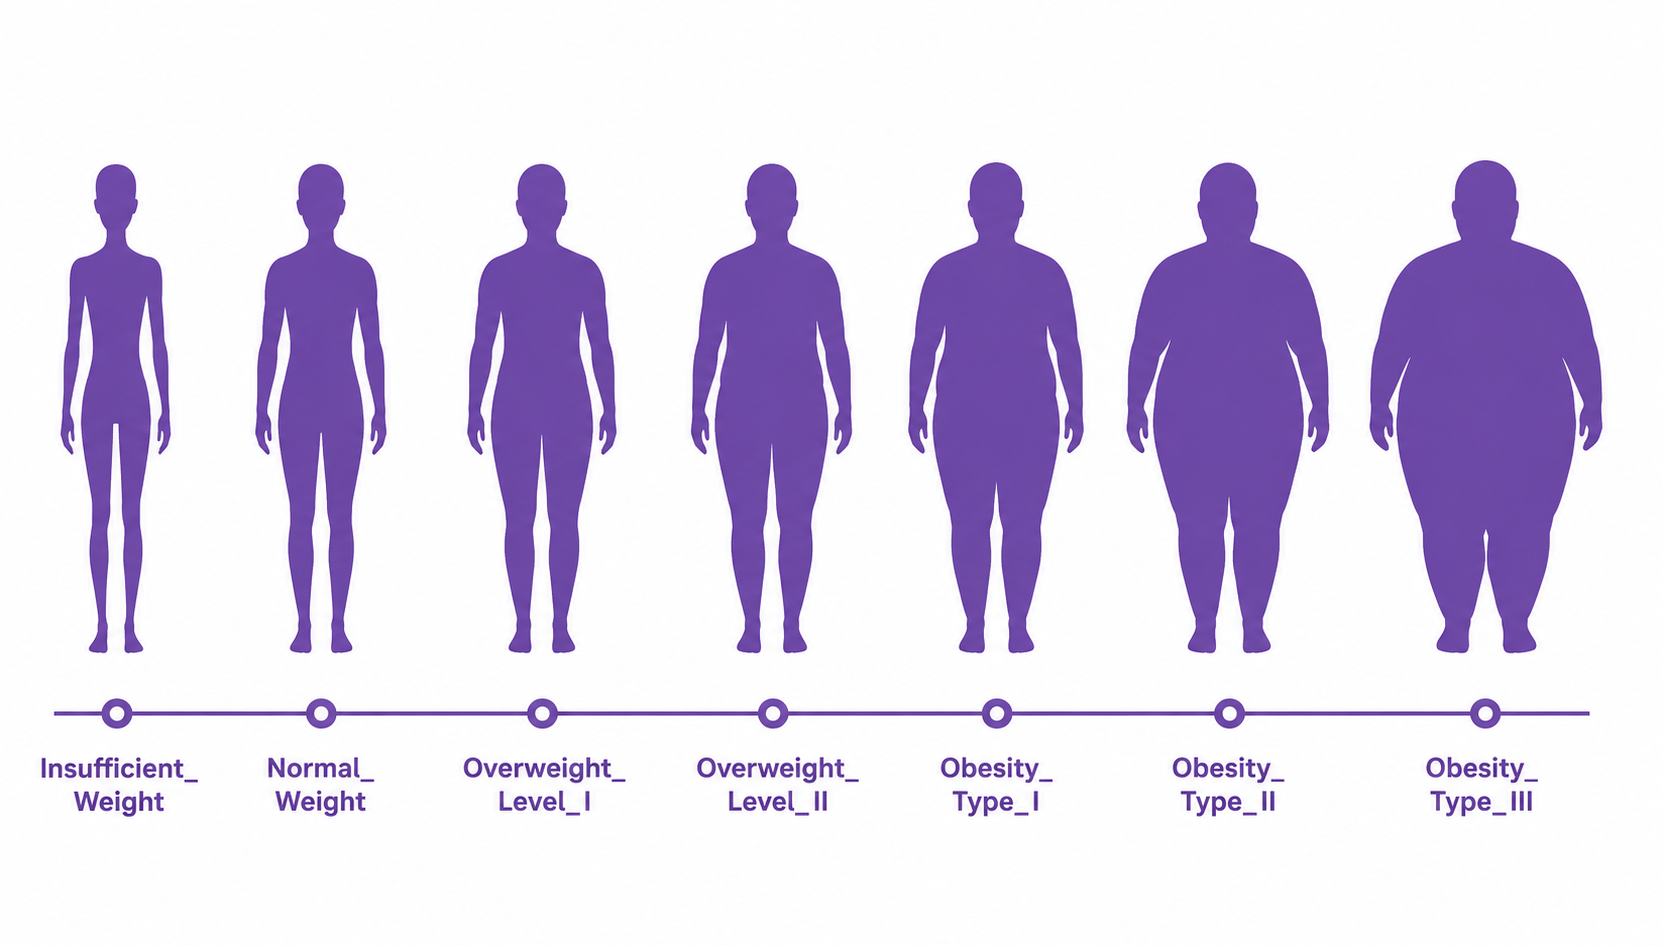

## Part 3: Step-by-Step Implementation

Now let's build the machine learning model step by step!

### Step 1: Import Required Libraries

In [32]:
# Import essential libraries
import pandas as pd                                    # Data manipulation and analysis
import numpy as np                                     # Numerical operations
import warnings                                        # Suppress warning messages
warnings.filterwarnings('ignore')

# Scikit-learn imports for machine learning
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier   # The main model

# Visualization and model saving
import matplotlib.pyplot as plt                        # For plotting graphs
import seaborn as sns                                  # For better visualizations
import joblib                                          # For saving/loading models

print("All libraries imported successfully!")

All libraries imported successfully!


### Step 2: Load and Explore the Dataset

**What we'll do:**
- Load the CSV file into a pandas DataFrame
- Examine the first few rows
- Check data types and missing values

In [33]:
# Load the dataset
df = pd.read_csv('../raw_csv/obesity_level.csv') 
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset Shape:
Rows: 20758, Columns: 18


In [34]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,0be1dad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,0,Automobile,0rmal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [35]:
# Check data types and missing values
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  str    
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  str    
 10  SMOKE                           20758 non-null  int64  
 11  CH2O                            20758 non-null  float64
 12  SCC                  

### we observe all columns are complete and no contains missing values but we can verify this 

In [36]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
0be1dad                           0
dtype: int64


In [37]:
print("\nBasic Statistics:")
df.describe()


Basic Statistics:


,id,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,0.819636,0.914443,2.445908,2.761332,0.011803,2.029418,0.033096,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.384500,0.279716,0.533218,0.705375,0.108000,0.608467,0.178891,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,1.000000,1.000000,2.000000,3.000000,0.000000,1.792022,0.000000,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,1.000000,1.000000,2.393837,3.000000,0.000000,2.000000,0.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,1.000000,1.000000,3.000000,3.000000,0.000000,2.549617,0.000000,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,1.000000,1.000000,3.000000,4.000000,1.000000,3.000000,1.000000,3.000000,2.000000


### for the column 'id' we can delete because not influence on this modele.
### for the columns 'Weight' we obsere max=165 

In [38]:
# Check the target variable distribution
print("\nTarget Variable Distribution (Obesity Levels):")
print(df.iloc[:, -1].value_counts())
# we can write also :
# print(df['0be1dad'].value_counts())


Target Variable Distribution (Obesity Levels):
0be1dad
Obesity_Type_III       4046
Obesity_Type_II        3248
0rmal_Weight           3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


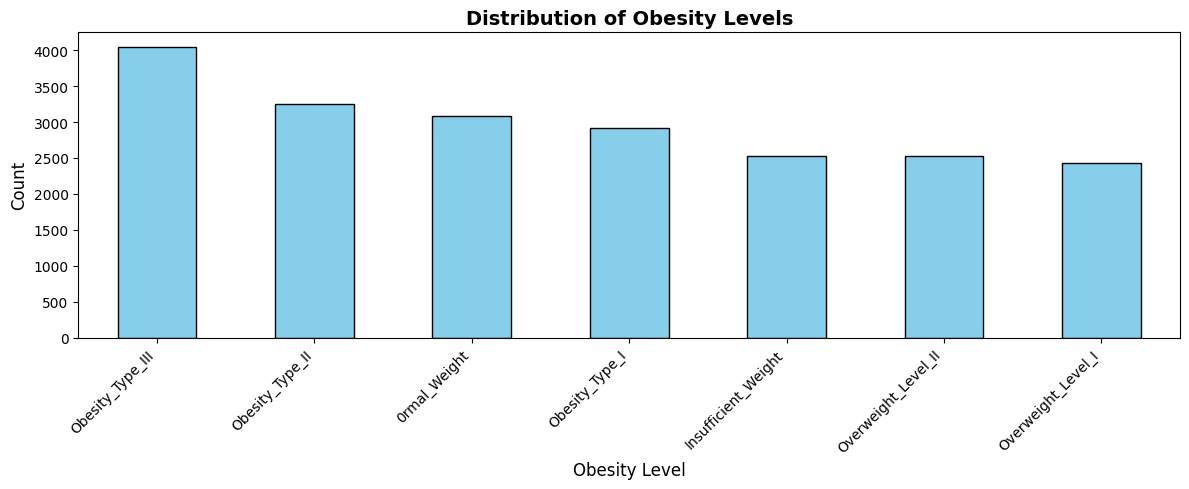

In [39]:
# Visualize the distribution
plt.figure(figsize=(12, 5))
df['0be1dad'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Obesity Levels', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Comment:

The target variable is fairly balanced across all obesity categories. Although Obesity Type III has the highest number of samples and Overweight Level I has the lowest, the differences are not extreme. This balanced distribution helps machine learning models learn all classes effectively and improves classification performance.

### Step 3: Data Preprocessing

**What we'll do:**
- Convert categorical variables to numerical values
- Separate features (X) from target variable (y)
- Scale numerical features

#### **Why Preprocessing is Important:**
- Machine learning algorithms work with numbers, not text
- Some algorithms are sensitive to feature scaling
- Proper preprocessing improves model performance

In [40]:
# Step 3.1: Create a copy to avoid modifying original data
df_processed = df.copy()

# Step 3.2: Identify categorical and numerical columns
categorical_columns = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df_processed.select_dtypes(include=['float64', 'int64']).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)
print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['Gender', 'CAEC', 'CALC', 'MTRANS', '0be1dad']

Numerical Columns:
['id', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE']


In [41]:
for col  in categorical_columns:
    print(df_processed[col].value_counts())
    print("="*60)


Gender
Female    10422
Male      10336
Name: count, dtype: int64
CAEC
Sometimes     17529
Frequently     2472
Always          478
0               279
Name: count, dtype: int64
CALC
Sometimes     15066
0              5163
Frequently      529
Name: count, dtype: int64
MTRANS
Public_Transportation    16687
Automobile                3534
Walking                    467
Motorbike                   38
Bike                        32
Name: count, dtype: int64
0be1dad
Obesity_Type_III       4046
Obesity_Type_II        3248
0rmal_Weight           3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


In [42]:
# Step 3.3: Separate target variable from features
target_column = df_processed.iloc[:, -1].name  # Last column is the target
X = df_processed.drop(columns=[target_column, 'id'])  # Remove target and id
y = df_processed[target_column]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (20758, 16)
Target (y) shape: (20758,)

Feature columns:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']


In [43]:
# Step 3.4: Encode Categorical Variables

# **LabelEncoder Explanation:**
# Converts categorical text to numbers (e.g., "Male" -> 1, "Female" -> 0)
# 1)
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'])
X['Gender'].value_counts()

Gender
0    10422
1    10336
Name: count, dtype: int64

In [44]:
# 2)
caec_map = {
    '0': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}

X['CAEC'] = X['CAEC'].map(caec_map)
X['CAEC'].value_counts()

CAEC
1    17529
2     2472
3      478
0      279
Name: count, dtype: int64

In [45]:
# 3)
calc_map = {
    '0': 0,
    'Sometimes': 1,
    'Frequently': 2
}

X['CALC'] = X['CALC'].map(calc_map)

In [46]:
print(X.columns)

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS'],
      dtype='str')


In [47]:
# 4)
X=pd.get_dummies(
    X,
    columns=['MTRANS'],
    drop_first=True
)

In [48]:
X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,1,0,2.763573,0,0.000000,0.976473,1,False,False,True,False
1,0,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,2,0,2.000000,0,1.000000,1.000000,0,False,False,False,False
2,0,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,1,0,1.910378,0,0.866045,1.673584,0,False,False,True,False
3,0,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,1,0,1.674061,0,1.467863,0.780199,1,False,False,True,False
4,1,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,1,0,1.979848,0,1.967973,0.931721,1,False,False,True,False


In [49]:
# Step 3.5: Encode Target Variable

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

| Variable       | Type                | Recommended Encoding               | Explanation                                                                                                                                                                                                  |
| -------------- | ------------------- | ---------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Gender**     | Nominal Categorical | Label Encoding or One-Hot Encoding | Gender has no natural order between categories (Male and Female). One-Hot Encoding is the most appropriate method, while Label Encoding is also acceptable for tree-based models such as Random Forest.      |
| **CAEC**       | Ordinal Categorical | Ordinal Encoding                   | CAEC represents the frequency of eating between meals (Never, Sometimes, Frequently, Always). Since these categories have a natural order, Ordinal Encoding preserves this ranking.                          |
| **CALC**       | Ordinal Categorical | Ordinal Encoding                   | CALC represents alcohol consumption frequency (Never, Sometimes, Frequently). The categories follow a logical order, making Ordinal Encoding the preferred choice.                                           |
| **MTRANS**     | Nominal Categorical | One-Hot Encoding                   | Transportation methods (Walking, Bike, Motorbike, Automobile, Public Transportation) do not have any meaningful order. One-Hot Encoding prevents the model from assuming a false ranking between categories. |
| **NObeyesdad** | Target Variable     | Label Encoding                     | The target variable must be converted into numerical labels so that machine learning algorithms can perform multi-class classification.                                                                      |


In [ ]:
df=pd.DataFrame(X)
df['0be1dad']=y
# 1. Exporter le dataset clean (avant scaling)
df.to_csv("../clean_csv/clean.csv", index=False)

In [56]:
# 2. Appliquer un scaler (StandardScaler ici)
df.drop(columns='0be1dad',inplace=True)
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df)

# 3. Créer un DataFrame avec les valeurs scalées
df_scaled = pd.DataFrame(scaled_values, columns=df.columns)
df_scaled['0be1dad']=y_encoded
# 4. Exporter le dataset transformé
df_scaled.to_csv("../clean_csv/scaled.csv", index=False)


In [57]:
# Step 3.6: Scale Numerical Features

# **StandardScaler Explanation:**
# Transforms features to have mean=0 and std=1
# Formula: (x - mean) / standard_deviation
# Why? Many algorithms perform better with scaled features
# Note: Random Forest doesn't require scaling, but it's good practice

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to keep column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Features (first 5 rows):")
print(X_scaled.head())
print("\n Features scaled successfully")

Scaled Features (first 5 rows):
     Gender       Age    Height    Weight  family_history_with_overweight  \
0  1.004152  0.105699 -0.002828 -0.235713                        0.469099   
1 -0.995866 -1.027052 -1.606291 -1.170931                        0.469099   
2 -0.995866 -1.027052  0.128451 -1.430012                        0.469099   
3 -0.995866 -0.507929  0.120090  1.644770                        0.469099   
4  1.004152  1.371197  2.450367  0.224054                        0.469099   

      FAVC      FCVC       NCP      CAEC     SMOKE      CH2O       SCC  \
0  0.30588 -0.836279  0.314684 -0.337845 -0.109287  1.206594 -0.185009   
1  0.30588 -0.836279  0.338364  1.889204 -0.109287 -0.048349 -0.185009   
2  0.30588 -1.060332 -1.913423 -0.337845 -0.109287 -0.195644 -0.185009   
3  0.30588  1.039171  0.338364 -0.337845 -0.109287 -0.584035 -0.185009   
4  0.30588  0.438397 -1.119801 -0.337845 -0.109287 -0.081469 -0.185009   

        FAF       TUE      CALC  MTRANS_Bike  MTRANS_Motorbi

### Step 4: Split Data into Training and Testing Sets

**Why Split the Data?**
- **Training Set (70%)**: Used to teach the model
- **Testing Set (30%)**: Used to evaluate if the model learned correctly
- Prevents "overfitting" (memorizing data instead of learning patterns)
- Gives realistic performance estimates on unseen data

In [58]:
# Split the data: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,              # Features
    y_encoded,             # Target
    test_size=0.3,         # 30% for testing
    random_state=42,       # For reproducibility
    stratify=y_encoded     # Keeps class distribution balanced
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 14530 samples
Testing set size: 6228 samples
Number of features: 19


In [59]:
print("\nClass Distribution in Training Set:")
unique, counts = np.unique(y_train, return_counts=True)
for obesity_level, count in zip(unique, counts):
    percentage = (count / len(y_train)) * 100
    print(f"Class {obesity_level}: {count} samples ({percentage:.2f}%)")

print("\nData split successfully (stratified to maintain class balance)")


Class Distribution in Training Set:
Class 0: 2157 samples (14.85%)
Class 1: 1766 samples (12.15%)
Class 2: 2037 samples (14.02%)
Class 3: 2274 samples (15.65%)
Class 4: 2832 samples (19.49%)
Class 5: 1699 samples (11.69%)
Class 6: 1765 samples (12.15%)

Data split successfully (stratified to maintain class balance)


### Step 5: Understanding Random Forest

#### **What is Random Forest?**
A powerful ensemble machine learning algorithm that works by:

1. **Creating Multiple Decision Trees**: Builds 100+ decision trees on random subsets of data
2. **Making Independent Decisions**: Each tree votes on the prediction
3. **Combining Votes**: Final prediction = majority vote (classification) or average (regression)

#### **Why Random Forest?**
- ✓ Handles both numerical and categorical data
- ✓ Naturally handles missing values
- ✓ Provides feature importance rankings
- ✓ Reduces overfitting through ensemble approach
- ✓ No feature scaling required
- ✓ Excellent for classification problems

#### **Key Parameters:**
- **n_estimators**: Number of trees to build (default=100, more = better but slower)
- **max_depth**: Maximum depth of each tree (prevents overfitting)
- **min_samples_split**: Minimum samples required to split a node
- **random_state**: For reproducibility
- **n_jobs**: Use -1 to use all processors (faster training)

### Step 6: Train the Random Forest Model

In [60]:
# Initialize the Random Forest Classifier
# We use simple parameters - no complex tuning yet
rf_model = RandomForestClassifier(
    n_estimators=100,           # Create 100 decision trees
    max_depth=15,               # Maximum tree depth (prevents overfitting)
    min_samples_split=5,        # Minimum samples to split a node
    min_samples_leaf=2,         # Minimum samples in leaf node
    random_state=42,            # For reproducibility
    n_jobs=-1,                  # Use all CPU cores
)

print("Random Forest Model Configuration:")
print(rf_model)

print("\n" + "="*80)
print("\nTraining the model... Please wait...\n")

# Train the model on training data
rf_model.fit(X_train, y_train)

print("\nModel trained successfully!")

Random Forest Model Configuration:
RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_jobs=-1, random_state=42)


Training the model... Please wait...


Model trained successfully!


### Step 7: Make Predictions

In [61]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Get prediction probabilities (optional)
y_pred_proba = rf_model.predict_proba(X_test)

print("Sample Predictions (first 10):")
print(y_pred[:10])

print("\nActual Values (first 10):")
print(y_test[:10])

print("\nPredictions made successfully!")

Sample Predictions (first 10):
[4 0 2 0 6 0 4 5 5 1]

Actual Values (first 10):
[4 0 2 0 6 0 4 5 5 1]

Predictions made successfully!


### Step 8: Evaluate Model Performance

**Evaluation Metrics Explained:**

1. **Accuracy**: Percentage of correct predictions
   - Formula: (Correct Predictions) / (Total Predictions)
   - Range: 0 to 1 (0% to 100%)

2. **Precision**: Of positive predictions, how many were actually correct?
   - Important when false positives are costly

3. **Recall**: Of actual positives, how many did we find?
   - Important when false negatives are costly

4. **F1-Score**: Harmonic mean of Precision and Recall
   - Best single metric for imbalanced data

5. **Confusion Matrix**: Shows breakdown of correct/incorrect predictions per class

In [62]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*80)
print("MODEL PERFORMANCE EVALUATION")
print("="*80)

print(f"\nACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("  └─ This means the model correctly predicted the obesity level in", 
      f"{accuracy*100:.2f}% of test cases")

print("\n" + "-"*80)
print("DETAILED CLASSIFICATION REPORT")
print("-"*80)
print(classification_report(y_test, y_pred, 
                           target_names=le_target.classes_,
                           digits=4))


MODEL PERFORMANCE EVALUATION

ACCURACY: 0.8937 (89.37%)
  └─ This means the model correctly predicted the obesity level in 89.37% of test cases

--------------------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
--------------------------------------------------------------------------------
                     precision    recall  f1-score   support

       0rmal_Weight     0.8443    0.8908    0.8669       925
Insufficient_Weight     0.9336    0.9287    0.9311       757
     Obesity_Type_I     0.8792    0.8671    0.8731       873
    Obesity_Type_II     0.9552    0.9630    0.9591       974
   Obesity_Type_III     0.9967    0.9959    0.9963      1214
 Overweight_Level_I     0.7963    0.7088    0.7500       728
Overweight_Level_II     0.7786    0.8177    0.7977       757

           accuracy                         0.8937      6228
          macro avg     0.8834    0.8817    0.8820      6228
       weighted avg     0.8935    0.8937    0.893

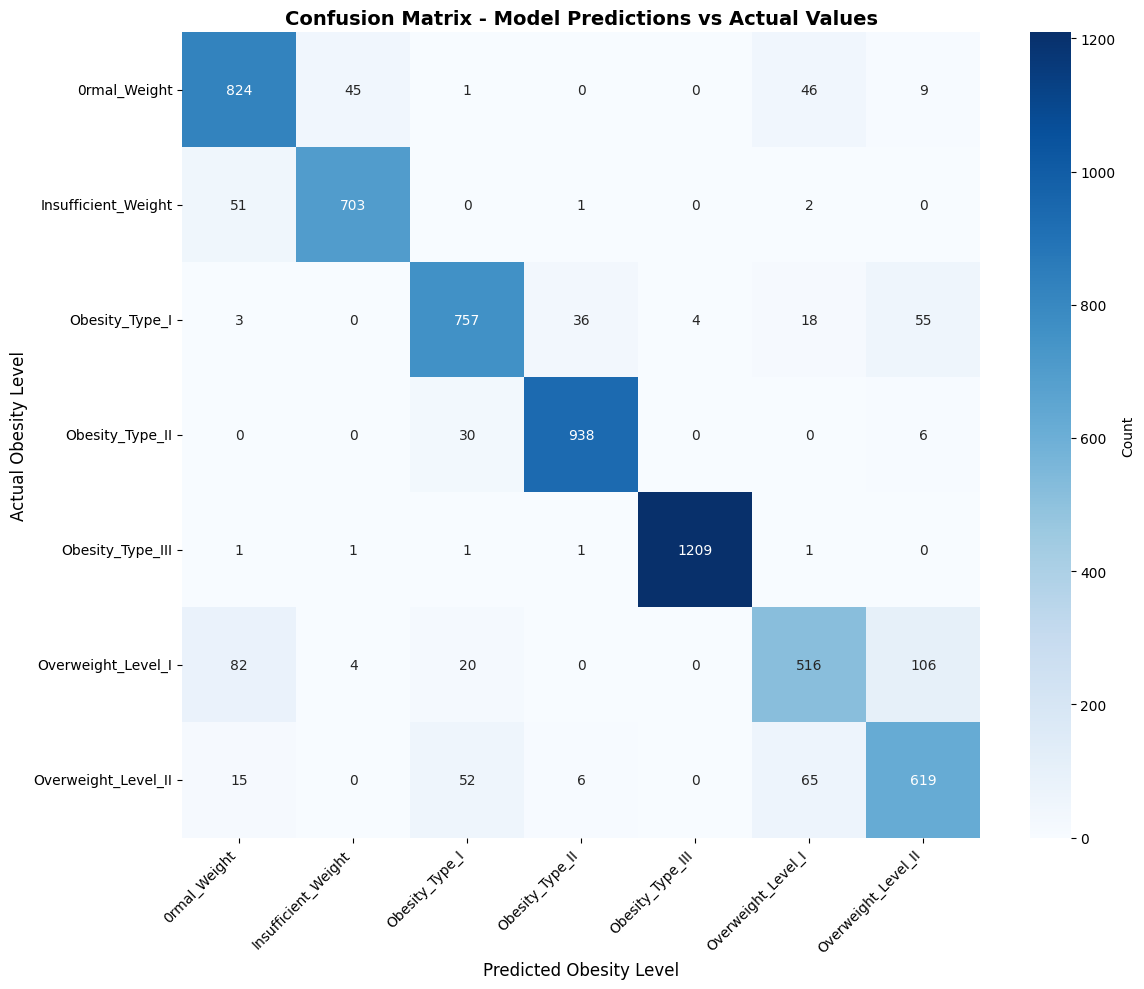

Confusion Matrix created


In [63]:
# Confusion Matrix - Visual representation of predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Model Predictions vs Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Actual Obesity Level', fontsize=12)
plt.xlabel('Predicted Obesity Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Confusion Matrix created")

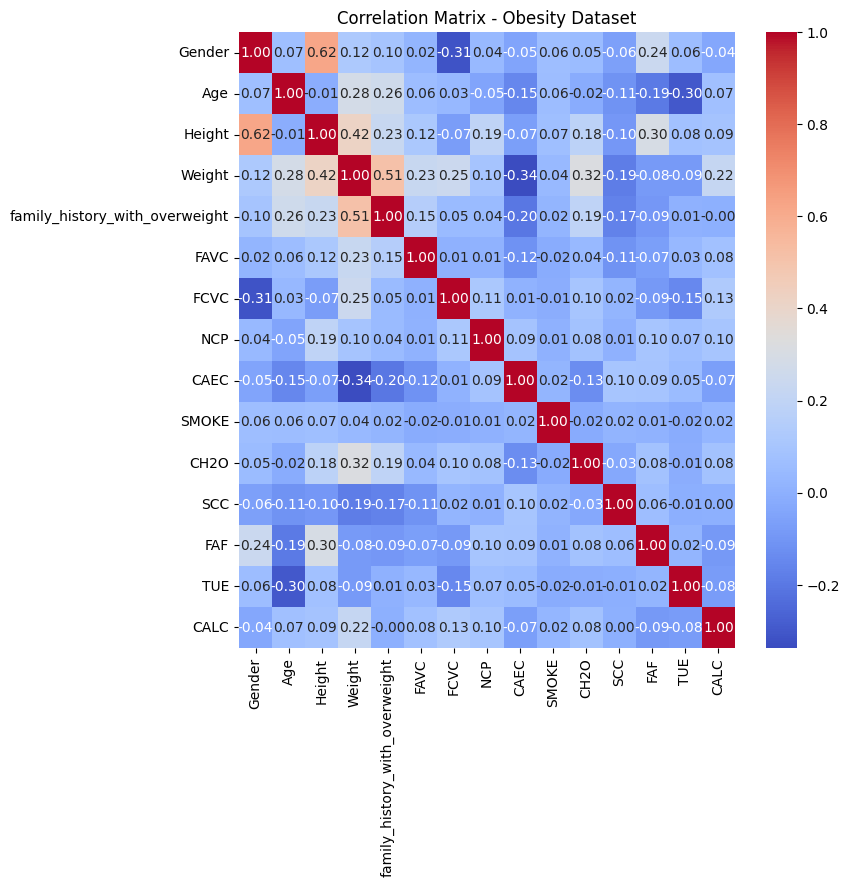

In [64]:
# correlaton matrix
# Sélectionner uniquement les colonnes numériques
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculer la matrice de corrélation
corr_matrix = numeric_df.corr()

# Afficher la heatmap
plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Obesity Dataset")
plt.show()


### Step 9: Feature Importance Analysis

**Why Feature Importance Matters:**
- Shows which features the model relies on most for predictions
- Helps identify the strongest obesity risk factors
- Guides healthcare professionals on what to prioritize
- Values range from 0 to 1 (higher = more important)

In [66]:
# Extract feature importances
feature_importances = rf_model.feature_importances_
feature_names = X.columns

# Sort by importance
sorted_idx = np.argsort(feature_importances)[::-1]

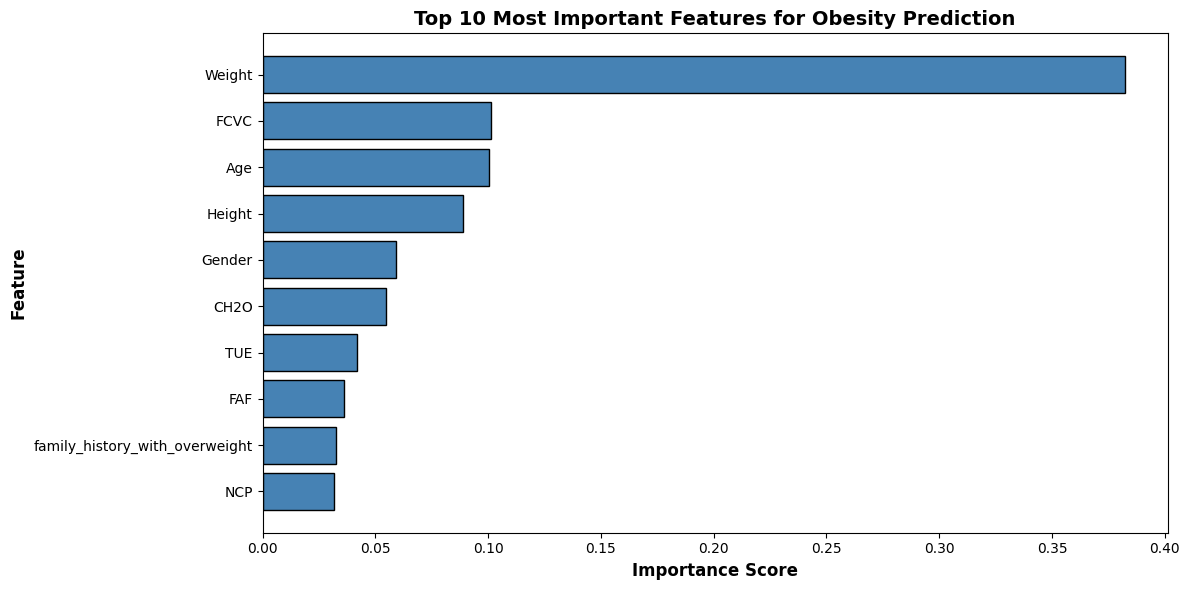

✓ Feature importance visualization created


In [67]:
# Visualize top 10 most important features
plt.figure(figsize=(12, 6))

top_10_idx = sorted_idx[:10]
top_10_features = feature_names[top_10_idx]
top_10_importances = feature_importances[top_10_idx]

plt.barh(range(len(top_10_features)), top_10_importances, color='steelblue', edgecolor='black')
plt.yticks(range(len(top_10_features)), top_10_features)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Important Features for Obesity Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

print("✓ Feature importance visualization created")

### Step 10: Save and Load the Model

**Why Save Models?**
- Training takes time and computational resources
- Once trained, we want to reuse the model without retraining
- Enables deployment in production environments
- Allows sharing models with other team members

**Pickle Format:**
- Standard Python format for serializing objects
- Easy to save and load
- Good for small to medium models
- File extension: .pkl

In [68]:
import os
# Save the trained model to a pickle file
model_filename = '../models/obesity_rf_model.pkl'
joblib.dump(rf_model, model_filename)

print(f"✓ Model saved successfully as '{model_filename}'")
print(f"  └─ File size: {os.path.getsize(model_filename) / 1024:.2f} KB")

✓ Model saved successfully as '../models/obesity_rf_model.pkl'
  └─ File size: 25124.84 KB


In [69]:
import joblib

preprocessing_data = {
    # Feature scaling
    "scaler": scaler,

    # Target encoder
    "target_encoder": le_target,

    # Ordinal encodings
    "caec_mapping": {
        "0": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    },

    "calc_mapping": {
        "0": 0,
        "Sometimes": 1,
        "Frequently": 2
    },

    # Feature names after preprocessing
    "feature_names": X.columns.tolist(),

    # Target class mapping
    "target_mapping": {
        class_name: int(label)
        for class_name, label in zip(
            le_target.classes_,
            le_target.transform(le_target.classes_)
        )
    }
}

joblib.dump(
    preprocessing_data,
    "../models/obesity_preprocessing.pkl"
)

print("Preprocessing pipeline saved successfully")

Preprocessing pipeline saved successfully


# Author
### <a href="https://www.linkedin.com/in/salma-belaicha-04a646336/" target="_blank">Salma Belaicha</a>